#  Psychometric evaluation of human vs LLM interview scores (RecruitView)

Two measurement methods on the same 76-question video interviews: **human** ratings (pairwise, from video) and an **LLM**-based method. All are decomposed with the **same engines** (GeneralizIT for classical G-theory + D-study, bambi for the Bayesian models), and each person's per-question scores are aggregated to one **BLUP universe score** per scale.

**Sections:**
1. DB cleaning & overview · 2. Human scores · 3. Evaluating the platform's existing LLM reports · 4. Comparison · 5. Psychometric fine-tuning LLM evaluation

In [23]:
import os
from pathlib import Path

_r = Path.cwd()
while not (_r / "data/recruitview_full.csv").exists() and _r != _r.parent:
    _r = _r.parent
os.chdir(_r)
print("working dir:", os.getcwd())


working dir: /Users/Olga/Documents/interview_hr


## Section 1. Database cleaning & overview

### 1.1 Cleaning (retakes and no-content answers)
- **Retakes** (`dup_keep=False`): the same candidate re-recorded the same question and for current analysis we keep the latest.
- **Answers ≤5 tokens**: no content to evaluate (the genuine no-content tail).

In [10]:
import pandas as pd, numpy as np
from scipy.stats import skew, kurtosis
pd.set_option("display.width", 170); pd.set_option("display.max_columns", 30)

raw = pd.read_csv("data/recruitview_full.csv")
rm = pd.read_csv("experiments/length_confound/results/response_metrics.csv")[["id", "n_tokens", "n_types"]]
dedup = raw[raw.dup_keep.astype(str).str.lower().isin(["true", "1"])]
d = dedup.merge(rm, on="id")
clean = d[d.n_tokens > 5].copy()

def line(char="─", n=60): return char * n

# ── cleaning ladder ────────────────────────────────────────────────
print(line("="))
print(" ANALYSIS SAMPLE — the numbers we work with downstream")
print(line("="))
print(f"  raw responses                 : {len(raw):5d}   ({raw.user_no.nunique()} persons)")
print(f"  − retakes (dup_keep=False)    : {len(raw)-len(dedup):5d}")
print(f"  − no-content (≤5 tokens)      : {len(d)-len(clean):5d}")
print(line("─"))
print(f"  ANALYSIS SAMPLE               : {len(clean):5d}   "
      f"({clean.user_no.nunique()} persons · {clean.question_id.nunique()} questions)")
print(f"      (3 persons dropped entirely — all answers ≤5 tokens)")

# ── coverage: questions answered per participant ───────────────────
nq = clean.groupby("user_no").question_id.nunique(); N = len(nq)
grp = {"6 questions": (nq == 6).sum(), "5 questions": (nq == 5).sum(),
       "7 questions": (nq == 7).sum(), "8–13 (multi-session)": (nq.between(8, 13)).sum(), "1–4 (partial)": nq.between(1, 4).sum()}
print(f"\n  questions per participant  (median {nq.median():.0f} · mean {nq.mean():.1f} · range {nq.min()}–{nq.max()}):")
for k, v in grp.items():
    print(f"      {k:22s}: {v:3d} persons ({v/N*100:4.1f}%)")

# ── content per response ───────────────────────────────────────────
def mmm(s): return f"min {s.min():.0f} · median {s.median():.0f} · mean {s.mean():.0f} · max {s.max():.0f}"
print(f"\n  answer length (tokens)        : {mmm(clean.n_tokens)}")
print(f"  vocabulary (types)            : {mmm(clean.n_types)}")
print(f"  delivery duration             : " +
      " · ".join(f"{k} {v}" for k, v in clean.duration.value_counts().items()))
print(line("="))


 ANALYSIS SAMPLE — the numbers we work with downstream
  raw responses                 :  2011   (331 persons)
  − retakes (dup_keep=False)    :    82
  − no-content (≤5 tokens)      :    44
────────────────────────────────────────────────────────────
  ANALYSIS SAMPLE               :  1885   (328 persons · 76 questions)
      (3 persons dropped entirely — all answers ≤5 tokens)

  questions per participant  (median 6 · mean 5.7 · range 1–13):
      6 questions           : 258 persons (78.7%)
      5 questions           :  25 persons ( 7.6%)
      7 questions           :  11 persons ( 3.4%)
      8–13 (multi-session)  :   8 persons ( 2.4%)
      1–4 (partial)         :  26 persons ( 7.9%)

  answer length (tokens)        : min 6 · median 60 · mean 70 · max 219
  vocabulary (types)            : min 6 · median 43 · mean 46 · max 129
  delivery duration             : medium 727 · short 611 · long 547


### 1.2 Sample composition & gender

Gender data was not provided in the dataset and was annotated manually.

In [12]:
persons = clean.groupby("user_no").gender.first()
pf, pm = (persons == 0).sum(), (persons == 1).sum()
rf, rm_ = (clean.gender == 0).sum(), (clean.gender == 1).sum()

print(line("─"))
print(" GENDER  (0 = female · 1 = male)")
print(line("─"))
print(f"  persons    : F {pf:4d} · M {pm:4d}   ({len(persons)} total · {100*pm/len(persons):.1f}% male)")
print(f"  responses  : F {rf:4d} · M {rm_:4d}   ({len(clean)} total · {100*rm_/len(clean):.1f}% male)")
print(f"  ⚠ female group < 100 persons — use small-sample thresholds for gender contrasts")
print(line("─"))


────────────────────────────────────────────────────────────
 GENDER  (0 = female · 1 = male)
────────────────────────────────────────────────────────────
  persons    : F   79 · M  249   (328 total · 75.9% male)
  responses  : F  475 · M 1410   (1885 total · 74.8% male)
  ⚠ female group < 100 persons — use small-sample thresholds for gender contrasts
────────────────────────────────────────────────────────────


### 1.3 Score-variable distributions (12 targets)
All scores are within-question **z-scores** (M≈0, SD≈1) derived by the RecruitView authors' nuclear-norm MNL model, not absolute ratings. Note the heavy **leptokurtosis** (kurtosis ≫ 0; extreme ±7…±10 tails are nuclear-norm artifacts) and **neuroticism's compressed** SD.
Only 7 scales are carried forward: those scorable from the transcript alone.

In [16]:
SCORES = ["openness","conscientiousness","extraversion","agreeableness","neuroticism","overall_personality",
          "interview_score","answer_score","speaking_skills","confidence_score","facial_expression","overall_performance"]
LLM7 = {"openness","conscientiousness","extraversion","agreeableness","neuroticism","answer_score","interview_score"}
desc = clean[SCORES].describe().T[["mean","std","min","max"]]
desc["skew"] = [round(skew(clean[c].dropna()),2) for c in SCORES]
desc["kurt"] = [round(kurtosis(clean[c].dropna()),2) for c in SCORES]
desc.insert(0, "LLM", ["*" if s in LLM7 else "" for s in SCORES])
print(desc.round(2).to_string())

# correlation matrix of the 7 targets (human z-scores)
corr7 = ["openness","conscientiousness","extraversion","agreeableness","neuroticism","answer_score","interview_score"]
C = clean[corr7].corr()
C.index = C.columns = [c[:5] for c in corr7]
print("\ncorrelation matrix — the 7 target scores (human z):")
print(C.round(2).to_string())


                    LLM  mean   std    min   max  skew   kurt
openness              * -0.02  1.11  -7.80  9.34 -0.15  13.04
conscientiousness     * -0.02  0.88  -6.93  6.62 -0.56  11.38
extraversion          * -0.02  1.07  -7.18  8.91 -0.56  12.04
agreeableness         * -0.04  1.18  -8.41  9.24  0.18  13.92
neuroticism           *  0.00  0.49  -2.58  2.23 -0.25   1.10
overall_personality     -0.04  1.19  -7.53  9.27  0.35  10.77
interview_score       * -0.04  1.21  -7.86  9.39  0.52  11.90
answer_score          * -0.03  1.11 -10.20  7.00  0.01  11.29
speaking_skills         -0.02  1.27  -9.41  7.90 -1.08  13.08
confidence_score        -0.03  1.06  -7.29  6.42 -0.73   8.62
facial_expression       -0.03  1.12  -7.46  7.47  0.29  10.21
overall_performance     -0.04  1.18  -9.31  8.85 -1.09  11.78

correlation matrix — the 7 target scores (human z):
       openn  consc  extra  agree  neuro  answe  inter
openn   1.00   0.56   0.74   0.53  -0.15   0.62   0.68
consc   0.56   1.00   0.47   0.

### 1.4 Question structure
Computed in [`src/stage1_question_similarity.py`](../src/stage1_question_similarity.py) (MiniLM
sentence embeddings → cosine). Confirms the reconstructed question-set design: several questions are
near-reformulations, so a person's answers are not to 76 independent prompts.

In [ ]:
qs = pd.read_csv("outputs/stage1_overview/question_similarity.csv")
seen, pairs = set(), []
for _, r in qs.iterrows():
    k = frozenset((int(r.question_id), int(r.nearest_qid)))
    if k in seen: continue
    seen.add(k); pairs.append((r.nearest_sim, int(r.question_id), int(r.nearest_qid), r.question, r.nearest_question))
pairs.sort(reverse=True)
print("closest question pairs (MiniLM cosine):")
for sim, a, b, qa, qb in pairs[:12]:
    print(f"  {sim:.2f}  Q{a:>2} <-> Q{b:>2}   {qa[:33]:33s} | {qb[:33]}")
q1 = qs[qs.question_id == 1].iloc[0]
print(f"\nQ1 'Introduce yourself' <-> Q76 'Tell me about yourself' are MUTUALLY nearest (cosine "
      f"{q1.nearest_sim}). These two questions are very similar and each participant answered just one of them.")


closest question pairs (MiniLM cosine):
  0.83  Q 2 <-> Q72   What are your greatest strengths  | What are your weaknesses?
  0.77  Q43 <-> Q61   Tell me about a time where you ex | Tell me about a time when you had
  0.76  Q28 <-> Q71   What is your dream company like?  | What is your dream job like?
  0.74  Q64 <-> Q60   Share a story of how you took own | Share a story of a project where 
  0.72  Q47 <-> Q 9   What motivates you to perform at  | What motivates you?
  0.72  Q59 <-> Q55   Tell me about a time when you had | Can you give an example of a time
  0.72  Q45 <-> Q74   Can you give an example of a situ | Can you give an example of a time
  0.71  Q54 <-> Q15   Tell me about a project you initi | Describe a project where you took
  0.70  Q50 <-> Q60   Share a story of a project where  | Share a story of a project where 
  0.67  Q69 <-> Q55   Can you give an example of a time | Can you give an example of a time
  0.67  Q 3 <-> Q51   How do you handle changes or unex | Describe 

### 1.5 Opportunity to express the construct
For each question, cosine with a Big-Five trait descriptor (**NEO-PI-R facet lists**) = an indirect proxy for whether the question gives the candidate a chance to express that trait (is it in the trait's semantic field?). A low OTE means the question is generic, so scoring that trait from such an answer rests on thin ground. It does not mean a participant could not express indicators of the construct when OTE is low.
These construct groupings can later help group questions to test how different questions affect scores.

In [17]:
ote = pd.read_csv("outputs/stage1_overview/question_construct_ote.csv")
print("best-fitting Big-Five construct per question (count of the 76):")
print(ote.best_construct.value_counts().to_string())
print(f"\nmean best-OTE = {ote.best_ote.mean():.2f}  (low => questions are fairly generic, not strongly trait-eliciting)")


traits = ["openness", "conscientiousness", "extraversion", "agreeableness", "neuroticism"]
print("\nhigh-OTE questions per trait (top quartile of the 76):")
print("  " + " · ".join(f"{t[:5]} {int(ote[f'high_{t}'].sum())}" for t in traits))
print("questions by #traits flagged:", ote.n_high_traits.value_counts().sort_index().to_dict(),
      f"  ({int((ote.n_high_traits==0).sum())} generic — express no trait strongly)")
print("\nbroadest questions (high on 3+ traits):")
print(ote[ote.n_high_traits >= 3][["question_id", "question", "n_high_traits", "high_traits"]]
      .sort_values("n_high_traits", ascending=False).to_string(index=False, max_colwidth=42))


best-fitting Big-Five construct per question (count of the 76):
best_construct
conscientiousness    27
openness             18
agreeableness        12
extraversion         11
neuroticism           8

mean best-OTE = 0.26  (low => questions are fairly generic, not strongly trait-eliciting)

high-OTE questions per trait (top quartile of the 76):
  openn 19 · consc 19 · extra 19 · agree 19 · neuro 20
questions by #traits flagged: {0: 30, 1: 22, 2: 9, 3: 5, 4: 9, 5: 1}   (30 generic — express no trait strongly)

broadest questions (high on 3+ traits):
 question_id                                   question  n_high_traits                                high_traits
           2 What are your greatest strengths and we...              5 openness, conscientiousness, extraversi...
           9                        What motivates you?              4 openness, extraversion, agreeableness, ...
          17 How would you rate yourself on a scale ...              4 openness, extraversion, agreeable

## Section 2. Human scores


### 2.1 Reliability as within-person consistency

Descriptive look at how consistent the human z-scores are across each participant's ~6 randomly
assigned questions, **per scale**, before the Generalizability-Theory analyses. For every
participant we take the mean z and the **within-person SD** across their answered questions, then
summarise the spread of those SDs over people. We also fit a one-way random-intercept model
`Rating ~ (1 | Person)` and report **ICC** = σ²person / (σ²person + σ²residual), the share of
variance that is stable between people before question effects are modelled.

Purely exploratory: within-person SD is **within-person variability, not reliability**. High SD +
low ICC simply means a person's scores move a lot from question to question, which is what
motivates the G-theory decomposition that follows.

In [24]:
import numpy as np
SC = ["openness","conscientiousness","extraversion","agreeableness","neuroticism","answer_score","interview_score"]

def icc_oneway(df, s):                       # unbalanced one-way random-effects components
    g = df.groupby("user_no")[s]; ni, mean_i = g.count(), g.mean()
    a, N, grand = len(ni), int(g.count().sum()), df[s].mean()
    ms_w = ((df[s] - df.user_no.map(mean_i))**2).sum() / (N - a)
    ms_b = (ni * (mean_i - grand)**2).sum() / (a - 1)
    k0 = (N - (ni**2).sum()/N) / (a - 1)
    s2p = max((ms_b - ms_w)/k0, 0.0)
    return dict(scale=s, ICC=round(s2p/(s2p+ms_w),3), s2_person=round(s2p,3), s2_resid=round(ms_w,3))

icc = pd.DataFrame([icc_oneway(clean, s) for s in SC])
rows = []
for s in SC:
    sd = clean.groupby("user_no")[s].std().dropna()
    q1, q3 = sd.quantile(.25), sd.quantile(.75)
    rows.append(dict(scale=s, n_persons=len(sd), mean=round(sd.mean(),3), median=round(sd.median(),3),
                     sd_of_sd=round(sd.std(),3), IQR=round(q3-q1,3), min=round(sd.min(),3), max=round(sd.max(),3)))
sd_summary = pd.DataFrame(rows)

print("=== ICC — one-way random intercept  Rating ~ (1|Person) ===")
print(icc.to_string(index=False))
print("\n=== within-person consistency — spread of participant SDs (variability, NOT reliability) ===")
print(sd_summary.to_string(index=False))


=== ICC — one-way random intercept  Rating ~ (1|Person) ===
            scale   ICC  s2_person  s2_resid
         openness 0.236      0.290     0.938
conscientiousness 0.208      0.160     0.609
     extraversion 0.268      0.310     0.845
    agreeableness 0.236      0.329     1.062
      neuroticism 0.183      0.044     0.199
     answer_score 0.286      0.355     0.885
  interview_score 0.241      0.351     1.105

=== within-person consistency — spread of participant SDs (variability, NOT reliability) ===
            scale  n_persons  mean  median  sd_of_sd   IQR   min   max
         openness        316 0.798   0.689     0.547 0.448 0.034 3.612
conscientiousness        316 0.658   0.583     0.411 0.346 0.026 2.829
     extraversion        316 0.763   0.676     0.501 0.388 0.038 3.556
    agreeableness        316 0.839   0.680     0.611 0.414 0.017 3.702
      neuroticism        316 0.413   0.404     0.163 0.210 0.072 1.104
     answer_score        316 0.796   0.705     0.517 0.423 0

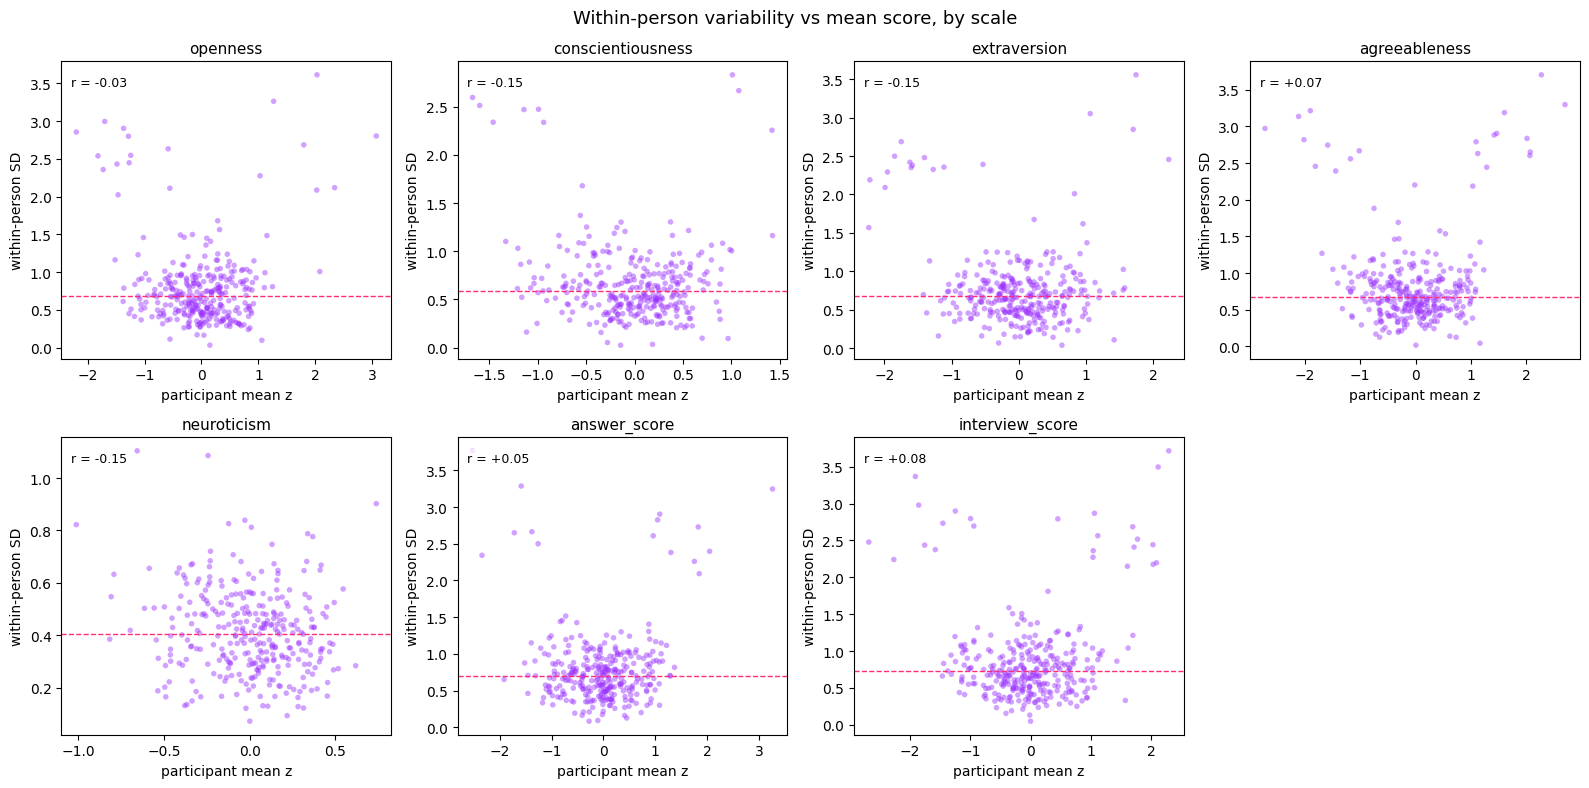

In [25]:
import matplotlib.pyplot as plt
VIOLET, MAGENTA = "#9B30FF", "#FF2D78"

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, s in zip(axes.ravel(), SC):
    g = clean.groupby("user_no")[s]
    p = pd.DataFrame({"mean_z": g.mean(), "sd": g.std()}).dropna()
    ax.scatter(p.mean_z, p.sd, s=16, alpha=.45, color=VIOLET, edgecolor="none")
    r = np.corrcoef(p.mean_z, p.sd)[0, 1]
    ax.axhline(p.sd.median(), color=MAGENTA, ls="--", lw=1)
    ax.set_title(s, fontsize=11)
    ax.set_xlabel("participant mean z"); ax.set_ylabel("within-person SD")
    ax.text(.03, .95, f"r = {r:+.2f}", transform=ax.transAxes, va="top",
            bbox=dict(boxstyle="round", fc="white", ec="none", alpha=.75), fontsize=9)
axes.ravel()[-1].axis("off")   # 8th panel empty (7 scales)
fig.suptitle("Within-person variability vs mean score, by scale", fontsize=13)
fig.tight_layout()
plt.show()


Approximately one quarter of the observed variance in ratings reflects stable between-person differences, while the remaining variance reflects within-person fluctuations across interview questions and residual variation.

### 2.2 Reliability G-theory & D-study

`VPC_person` = share of a single rating's variance that is stable between-person (true) signal.

Rule: trust ≥.50 VPC · marginal Eρ²(6)≥.70 · else do-not-trust.
`n→.70` = D-study questions.

Variance components: `sigma2_person` (stable between-person signal), `sigma2_question` (how much questions differ in difficulty), `sigma2_resid` (within-person noise). Two reliabilities follow: `Ero2_6` (relative, for ranking people) and `Phi_6` (absolute, for a fixed pass/fail bar). Phi counts question difficulty as error, so Phi ≤ Ero2. Human scores are z-scored within question, so `sigma2_question` is about 0 and `Phi_6` equals `Ero2_6`.

In [46]:
import warnings, io, re, math, contextlib
import numpy as np
import pandas as pd
from pathlib import Path

warnings.filterwarnings("ignore")
ROOT = Path.cwd()   # notebook: the setup cell chdir'd to the repo root
OUT = ROOT / "outputs/stage2_human"
SCALES = ["openness", "conscientiousness", "extraversion", "agreeableness",
          "neuroticism", "answer_score", "interview_score"]


def components(d: pd.DataFrame, scale: str):
    """Classical p x question variance components (person, question, residual)."""
    from generalizit import GeneralizIT
    dd = d[["user_no", "question_id", scale]].dropna().rename(columns={"user_no": "Person"})
    with contextlib.redirect_stdout(io.StringIO()):          # silence GeneralizIT chatter
        g = GeneralizIT(data=dd, design_str="Person x question_id", response=scale)
        g.calculate_anova(); g.calculate_g_coefficients()
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        g.variance_summary()
    v = buf.getvalue()
    sp = float(re.search(r"(?m)^person\s+(-?\d+\.\d+)", v).group(1))
    sq = float(re.search(r"(?m)^question_id\s+(-?\d+\.\d+)", v).group(1))
    sr = float(re.search(r"(?m)^person x question_id\s+(-?\d+\.\d+)", v).group(1))
    return max(sp, 0.0), max(sq, 0.0), max(sr, 0.0)


def main() -> None:
    OUT.mkdir(parents=True, exist_ok=True)
    d = pd.read_csv(ROOT / "data/recruitview_analysis.csv")
    rows = []
    for s in SCALES:
        sp, sq, sr = components(d, s)
        vpc = sp / (sp + sr) if (sp + sr) > 0 else float("nan")
        ero6 = sp / (sp + sr / 6) if (sp + sr / 6) > 0 else float("nan")
        phi6 = sp / (sp + (sq + sr) / 6) if (sp + (sq + sr) / 6) > 0 else float("nan")
        cls = "trust" if vpc >= 0.50 else ("marginal" if ero6 >= 0.70 else "do-not-trust")
        def nfor(rho): return (rho / (1 - rho)) * (sr / sp) if sp > 0 else float("inf")
        rows.append(dict(scale=s, sigma2_person=round(sp, 3), sigma2_question=round(sq, 3),
                         sigma2_resid=round(sr, 3), VPC_person=round(vpc, 3), Ero2_6=round(ero6, 3),
                         Phi_6=round(phi6, 3), ceiling=round(math.sqrt(ero6), 3), classification=cls,
                         n_for_rho070=round(nfor(0.70), 1), n_for_rho080=round(nfor(0.80), 1)))
    pd.DataFrame(rows).to_csv(OUT / "human_reliability.csv", index=False)
    print(f"Human G-theory reliability (clean analysis sample n={len(d)}) -> wrote human_reliability.csv")


if __name__ == "__main__":
    main()

# display the same curated columns as the LLM side (Section 3.3), read back from the CSV
hr = pd.read_csv(OUT / "human_reliability.csv")
print(hr[["scale", "sigma2_person", "sigma2_resid", "VPC_person", "Ero2_6", "Phi_6",
          "n_for_rho070", "classification"]].to_string(index=False))


Human G-theory reliability (clean analysis sample n=1885) -> wrote human_reliability.csv
            scale  sigma2_person  sigma2_resid  VPC_person  Ero2_6  Phi_6  n_for_rho070 classification
         openness          0.289         0.983       0.227   0.638  0.638           7.9   do-not-trust
conscientiousness          0.159         0.639       0.199   0.599  0.599           9.4   do-not-trust
     extraversion          0.309         0.887       0.258   0.676  0.676           6.7   do-not-trust
    agreeableness          0.328         1.113       0.227   0.638  0.638           7.9   do-not-trust
      neuroticism          0.044         0.208       0.175   0.560  0.560          11.0   do-not-trust
     answer_score          0.354         0.923       0.277   0.697  0.697           6.1   do-not-trust
  interview_score          0.350         1.157       0.232   0.645  0.645           7.7   do-not-trust


### 2.3 How much of the signal is response length
Three nested models per scale: **m1** (gender only) → **wc** (+ log word-count) → **ms** (+ Flesch-Kincaid readability). The first table reports the **variance components** (σ²person / σ²question / σ²residual) **before and after adjustment for response length**, so it is visible which component changes.

- `person_before → person_after`, and `VPC_m1 → VPC_wc`: **change in VPC after adjustment for response length**.
- `length_b`: length slope; a negative value means longer responses were associated with lower ratings.
- `FK_b`: readability slope (adds ≈0 beyond length).
- `gender_before → gender_after` and `gender_atten_%`: **gender-coefficient attenuation after adjustment for response length**.

In [ ]:
import logging
import warnings
import numpy as np
import pandas as pd
import bambi as bmb
from pathlib import Path

warnings.filterwarnings("ignore")
# silence PyMC sampler chatter ("Initializing NUTS...", "Sampling 4 chains...") and arviz
# convergence notes. Must be AFTER importing bambi/pymc — pymc resets its logger level on import.
for _lg in ("pymc", "arviz"):
    logging.getLogger(_lg).setLevel(logging.ERROR)
ROOT = Path.cwd()   # notebook: the setup cell chdir'd to the repo root
OUT = ROOT / "outputs/stage2_human"
SCALES = ["openness", "conscientiousness", "extraversion", "agreeableness",
          "neuroticism", "answer_score", "interview_score"]
RE = "(1|user_no) + (1|question_id)"


def _var_components(idata):
    """Posterior-mean variance components (person, question, residual)."""
    p = idata.posterior
    sp = float((p["1|user_no_sigma"] ** 2).mean())
    sq = float((p["1|question_id_sigma"] ** 2).mean())
    sr = float((p["sigma"] ** 2).mean())
    return sp, sq, sr


def _vpc(sp, sq, sr):
    """Person VPC = sigma2_person / (sigma2_person + sigma2_question + sigma2_residual)."""
    return sp / (sp + sq + sr)


def _coef(idata, name):
    if name in idata.posterior:
        v = idata.posterior[name].values.reshape(-1)
        return v.mean(), np.percentile(v, 2.5), np.percentile(v, 97.5)
    return (np.nan, np.nan, np.nan)


def _atten(g_base, g_adj):
    """% attenuation of the gender coefficient; NaN when the baseline effect is ~0
    (95% CI crosses 0) — otherwise dividing by a near-zero gender effect is meaningless."""
    if not (g_base[1] < 0 < g_base[2]) and g_base[0]:
        return 100 * (1 - g_adj[0] / g_base[0])
    return np.nan


def _print_tables(tab: pd.DataFrame) -> None:
    """English summary tables of the ladder (m1 -> +length -> +readability)."""
    print("Answer-length & readability ladder — human z-scores")
    print("  m1 = gender only  |  wc = + log word-count  |  ms = + Flesch-Kincaid readability\n")

    vc = tab[["scale", "s2_person_m1", "s2_person_wc", "s2_question_m1", "s2_question_wc",
              "s2_resid_m1", "s2_resid_wc"]].copy()
    vc.columns = ["scale", "person_before", "person_after", "question_before", "question_after",
                  "residual_before", "residual_after"]
    print("Variance components before vs after adjustment for response length:")
    print(vc.to_string(index=False))

    sl = tab[["scale", "VPC_m1", "VPC_wc", "VPC_ms", "logwc_b_wc", "fk_b",
              "gender_m1", "gender_wc", "gender_atten_wc"]].copy()
    sl.columns = ["scale", "VPC_m1", "VPC_wc", "VPC_ms", "length_b", "FK_b",
                  "gender_before", "gender_after", "gender_atten_%"]
    print("\nVPC across the ladder, length/readability slopes, and gender:")
    print("  length_b < 0 = longer responses were associated with lower ratings;")
    print("  gender_atten_% = gender-coefficient attenuation after adjustment for response length.")
    print(sl.to_string(index=False))


def main() -> None:
    OUT.mkdir(parents=True, exist_ok=True)
    d = pd.read_csv(ROOT / "data/recruitview_analysis.csv")
    st = pd.read_csv(ROOT / "experiments/length_confound/results/style_metrics.csv")
    d = d.merge(st[["id", "fk_grade"]], on="id", how="left")
    d["user_no"] = d["user_no"].astype(str)
    d["question_id"] = d["question_id"].astype(str)
    d["gender"] = pd.Categorical(d["gender"].map({0: "F", 1: "M"}), categories=["F", "M"])
    lg = np.log1p(d["n_tokens"])
    d["log_wc_z"] = (lg - lg.mean()) / lg.std()
    d["fk_z"] = (d["fk_grade"] - d["fk_grade"].mean()) / d["fk_grade"].std()

    rows = []
    for t in SCALES:
        # same rows for all three nested models (drop where FK is missing too)
        dd = d[["user_no", "question_id", "gender", "log_wc_z", "fk_z", t]].dropna().rename(columns={t: "y"})
        fit = lambda f: bmb.Model(f, dd, family="gaussian").fit(
            draws=800, tune=800, chains=4, cores=1, target_accept=0.9, random_seed=7, progressbar=False)
        i1 = fit(f"y ~ 1 + gender + {RE}")
        iw = fit(f"y ~ 1 + gender + log_wc_z + {RE}")
        im = fit(f"y ~ 1 + gender + log_wc_z + fk_z + {RE}")

        sp1, sq1, sr1 = _var_components(i1)
        spw, sqw, srw = _var_components(iw)
        spm, sqm, srm = _var_components(im)
        g1, gw, gm = _coef(i1, "gender"), _coef(iw, "gender"), _coef(im, "gender")
        lw, lm = _coef(iw, "log_wc_z"), _coef(im, "log_wc_z")
        fk = _coef(im, "fk_z")
        rows.append(dict(
            scale=t, n=len(dd),
            # variance components — person / question / residual, BEFORE (m1) and AFTER (wc) length
            s2_person_m1=round(sp1, 3), s2_person_wc=round(spw, 3), s2_person_ms=round(spm, 3),
            s2_question_m1=round(sq1, 3), s2_question_wc=round(sqw, 3),
            s2_resid_m1=round(sr1, 3), s2_resid_wc=round(srw, 3), s2_resid_ms=round(srm, 3),
            # change in each component after adjustment for response length (which component moves)
            d_person_len=round(spw - sp1, 3), d_question_len=round(sqw - sq1, 3),
            d_resid_len=round(srw - sr1, 3), d_person_fk=round(spm - spw, 3),
            # collapsed person-VPC across the ladder
            VPC_m1=round(_vpc(sp1, sq1, sr1), 3), VPC_wc=round(_vpc(spw, sqw, srw), 3),
            VPC_ms=round(_vpc(spm, sqm, srm), 3),
            # gender effect (M-F) and its attenuation after each adjustment
            gender_m1=round(g1[0], 3), gender_wc=round(gw[0], 3), gender_ms=round(gm[0], 3),
            gender_atten_wc=round(_atten(g1, gw), 1), gender_atten_ms=round(_atten(g1, gm), 1),
            # slopes (standardised); negative = longer / more-complex responses -> lower rating
            logwc_b_wc=round(lw[0], 3), logwc_b_ms=round(lm[0], 3),
            fk_b=round(fk[0], 3), fk_lo=round(fk[1], 3), fk_hi=round(fk[2], 3)))
    tab = pd.DataFrame(rows)
    tab.to_csv(OUT / "human_length_ladder.csv", index=False)
    _print_tables(tab)


if __name__ == "__main__":
    main()


Answer-length & readability ladder — human z-scores
  m1 = gender only  |  wc = + log word-count  |  ms = + Flesch-Kincaid readability

Variance components before vs after adjustment for response length:
            scale  person_before  person_after  question_before  question_after  residual_before  residual_after
         openness          0.285         0.125            0.001           0.001            0.936           0.916
conscientiousness          0.160         0.090            0.000           0.001            0.608           0.601
     extraversion          0.304         0.202            0.001           0.001            0.844           0.840
    agreeableness          0.319         0.168            0.001           0.001            1.060           1.048
      neuroticism          0.047         0.036            0.000           0.000            0.198           0.197
     answer_score          0.353         0.170            0.001           0.002            0.884           0.879
  int

- Response length was consistently associated with human ratings across most scales. Longer responses tended to receive lower ratings for openness, conscientiousness, extraversion, agreeableness, answer quality, and overall interview quality, whereas neuroticism showed virtually no association with response length.
- Adjusting for response length substantially reduced the estimated between-person variance. Across most scales, the person variance component decreased by approximately 35-55%, indicating that a considerable portion of the observed differences between candidates was statistically associated with response length.
- Question-level variance was negligible throughout. The random question effect remained close to zero before and after adjustment, suggesting that interview questions did not systematically differ in their average rating levels.
- Residual variance changed very little after adjustment. Including response length did not meaningfully reduce unexplained within-person variability across interview responses.
- Consequently, the variance partition coefficient (VPC) decreased markedly after adjustment. This reduction was driven primarily by the decrease in the person variance component rather than by changes in question or residual variance.
- Gender effects were attenuated after accounting for response length. Across most scales, the estimated gender coefficient was reduced by approximately 15-24%, suggesting that part of the observed gender differences was statistically associated with differences in response length.
- Readability (Flesch-Kincaid) contributed little beyond response length. Readability coefficients were consistently close to zero across all scales, indicating minimal additional explanatory value.

### 2.4 ⭐ Transformation from per-question ratings to one score per person
Each participant answered ~6 questions; here we collapse those to **one score per person per scale**.
Not the raw mean: the **EB/BLUP universe score** (empirical-Bayes / Best Linear Unbiased Predictor)
shrinks each person toward the grand mean **by their reliability** (n-dependent), so people with few or
noisy answers are pulled harder toward 0.

Table columns:
- `sd_raw`: spread of the **raw** per-person means across the 328 persons.
- `sd_blup`: spread **after** shrinkage (always smaller).
- `shrink_pct` = `100·(1 − sd_blup/sd_raw)`: how much the spread shrank. **High = the scale is
  unreliable**, so between-person differences are trusted less and pulled toward 0 more.
- `corr_blup_raw` ≈ 0.99: person **ranking is preserved**; shrinkage rescales, it does not reorder.

The chart below shows, per scale, the **raw** distribution vs the **BLUP** distribution; the visible
narrowing is the shrinkage.

In [19]:
import numpy as np
b = pd.read_csv("outputs/stage2_human/human_person_scores_blup.csv")
SC = ["openness","conscientiousness","extraversion","agreeableness","neuroticism","answer_score","interview_score"]
rows = []
for s in SC:
    bl, rw = b[f"{s}_blup"], b[f"{s}_rawmean"]
    rows.append(dict(scale=s, sd_raw=round(rw.std(),3), sd_blup=round(bl.std(),3),
                     shrink_pct=round(100*(1-bl.std()/rw.std()),1),
                     corr_blup_raw=round(np.corrcoef(bl,rw)[0,1],3)))
print(f"per-person BLUP scores: {len(b)} persons x {len(SC)} scales\n")
print(pd.DataFrame(rows).to_string(index=False))

per-person BLUP scores: 328 persons x 7 scales

            scale  sd_raw  sd_blup  shrink_pct  corr_blup_raw
         openness   0.679    0.430        36.6          0.990
conscientiousness   0.519    0.309        40.6          0.988
     extraversion   0.681    0.457        32.9          0.991
    agreeableness   0.725    0.459        36.7          0.991
      neuroticism   0.282    0.159        43.5          0.990
     answer_score   0.724    0.497        31.3          0.992
  interview_score   0.747    0.474        36.5          0.989


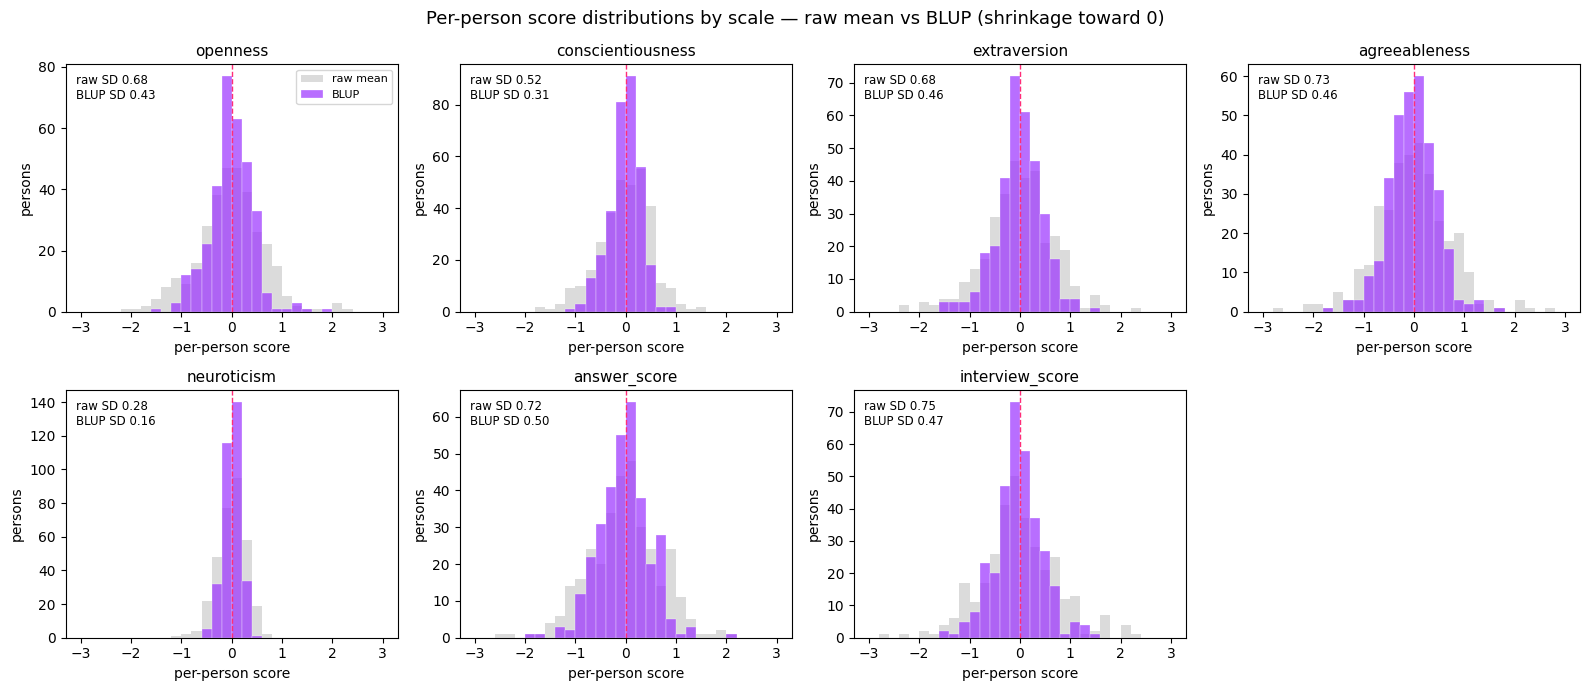

In [28]:
import matplotlib.pyplot as plt
import numpy as np
VIOLET, MAGENTA, GREY = "#9B30FF", "#FF2D78", "#B0B0B0"

b = pd.read_csv("outputs/stage2_human/human_person_scores_blup.csv")
SC = ["openness","conscientiousness","extraversion","agreeableness","neuroticism","answer_score","interview_score"]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
bins = np.linspace(-3, 3, 31)
for ax, s in zip(axes.ravel(), SC):
    raw, bl = b[f"{s}_rawmean"].dropna(), b[f"{s}_blup"].dropna()
    ax.hist(raw, bins=bins, color=GREY, alpha=.45, label="raw mean", edgecolor="none")
    ax.hist(bl, bins=bins, color=VIOLET, alpha=.70, label="BLUP", edgecolor="white", linewidth=.3)
    ax.axvline(0, color=MAGENTA, ls="--", lw=1)
    ax.set_title(s, fontsize=11)
    ax.set_xlabel("per-person score"); ax.set_ylabel("persons")
    ax.text(.03, .96, f"raw SD {raw.std():.2f}\nBLUP SD {bl.std():.2f}", transform=ax.transAxes,
            va="top", fontsize=8.5, bbox=dict(boxstyle="round", fc="white", ec="none", alpha=.75))
axes.ravel()[0].legend(fontsize=8, loc="upper right")
axes.ravel()[-1].axis("off")   # 8th panel empty (7 scales)
fig.suptitle("Per-person score distributions by scale — raw mean vs BLUP (shrinkage toward 0)", fontsize=13)
fig.tight_layout()
plt.show()


## Section 3. Evaluating the platform's existing LLM reports

The **same** G-theory + Bayesian decomposition, on the LLM scores, ending with per-person BLUP, a mirror of Section 2. **Scoring method:** OpenAI `gpt-4o-mini` acts as a content-analysis coder of each Gemini **video-report**, converting its stated verdict into an absolute score per scale (Big Five + `answer_score` = 1-5; `interview_score` = 0-2; `null` = coder abstention). It does NOT re-assess the candidate.

### 3.1 Coding coverage & abstention
`null` scores are coder abstentions, not zeros, and are listwise-dropped per scale. High-abstention scales
(≥25 %) are flagged **provisional** and must not be headlined (the missingness is non-random).

In [11]:
import pandas as pd
tr = pd.read_csv("outputs/stage3_teas/teas_reliability.csv")
print(tr[["scale","n_scored","abstention_pct","provisional_abstention"]].to_string(index=False))

            scale  n_scored  abstention_pct  provisional_abstention
         openness      1202       36.233422                    True
conscientiousness      1730        8.222812                   False
     extraversion      1698        9.920424                   False
    agreeableness      1059       43.819629                    True
      neuroticism      1858        1.432361                   False
     answer_score      1884        0.053050                   False
  interview_score      1885        0.000000                   False


### 3.2 Reliability as within-person consistency (LLM)
The **same** one-way random-intercept ICC as Section 2.1, now on the LLM scores: a person's ~6
LLM-coded answers → `Score ~ (1 | Person)`, **ICC** = σ²person / (σ²person + σ²residual) = the share
of a single LLM score's variance that is stable between people (before question effects are modelled).

Raw Likert is used, and **ICC is scale-invariant, so it is directly comparable to the human ICC** in
2.1. `n_scored` shrinks on the high-abstention scales (openness, agreeableness); read those two ICCs
as provisional (the missingness is non-random).

In [ ]:
import numpy as np
# LLM scores are row-level in the scorer output; merge to the analysis sample via response_id.
teas = pd.read_csv("experiments/evaluation_of_gemini_outputs/results/teas_run2_gpt-4o-mini.csv")
SC = ["openness","conscientiousness","extraversion","agreeableness","neuroticism","answer_score","interview_score"]
tdf = clean[["response_id","user_no","question_id"]].merge(
    teas[["response_id"] + [f"E_{s}" for s in SC]], on="response_id", how="inner")


def icc_oneway(df, col):                      # unbalanced one-way random-effects components
    d = df[["user_no", col]].dropna()         # drop abstentions (null E_) per scale
    g = d.groupby("user_no")[col]; ni, mean_i = g.count(), g.mean()
    a, N, grand = len(ni), int(ni.sum()), d[col].mean()
    ms_w = ((d[col] - d.user_no.map(mean_i))**2).sum() / (N - a)
    ms_b = (ni * (mean_i - grand)**2).sum() / (a - 1)
    k0 = (N - (ni**2).sum()/N) / (a - 1)
    s2p = max((ms_b - ms_w)/k0, 0.0)
    return dict(scale=col.replace("E_",""), n_persons=a, n_scored=N,
                ICC=round(s2p/(s2p+ms_w),3), s2_person=round(s2p,3), s2_resid=round(ms_w,3))

icc_llm = pd.DataFrame([icc_oneway(tdf, f"E_{s}") for s in SC])

print("=== ICC (LLM/TEAS) — one-way random intercept  Score ~ (1|Person) ===")
print("   raw Likert; ICC is scale-invariant → directly comparable to the human ICC in 2.1")
print(icc_llm.to_string(index=False))


=== ICC (LLM/TEAS) — one-way random intercept  Score ~ (1|Person) ===
   raw Likert; ICC is scale-invariant → directly comparable to the human ICC in 2.1
            scale  n_persons  n_scored   ICC  s2_person  s2_resid
         openness        323      1202 0.141      0.239     1.461
conscientiousness        325      1730 0.272      0.566     1.517
     extraversion        327      1698 0.295      0.180     0.431
    agreeableness        306      1059 0.137      0.136     0.857
      neuroticism        328      1858 0.232      0.171     0.565
     answer_score        327      1884 0.361      0.716     1.266
  interview_score        328      1885 0.320      0.152     0.323


### 3.3 Reliability G-theory & D-study LLM scores
Same rule as Section 2 (trust ≥.50 VPC · marginal Eρ²(6)≥.70 · else do-not-trust, fixed n=6).

Same components and reliabilities as 2.2. TEAS uses raw Likert (not within-question z), so `sigma2_question` is non-zero and `Phi_6` (absolute) drops below `Ero2_6` (relative). That gap shows how much question difficulty erodes absolute-decision reliability, a comparability concern since candidates answer different questions.

In [40]:
import warnings, io, re, contextlib
import numpy as np
import pandas as pd
from pathlib import Path

warnings.filterwarnings("ignore")
ROOT = Path.cwd()   # notebook: the setup cell chdir'd to the repo root
SCALES = ["openness", "conscientiousness", "extraversion", "agreeableness",
          "neuroticism", "answer_score", "interview_score"]


def components(d: pd.DataFrame, col: str):
    """Classical p x question variance components (person, question, residual)."""
    from generalizit import GeneralizIT
    dd = d[["user_no", "question_id", col]].dropna().rename(columns={"user_no": "Person"})
    with contextlib.redirect_stdout(io.StringIO()):          # silence GeneralizIT chatter
        g = GeneralizIT(data=dd, design_str="Person x question_id", response=col)
        g.calculate_anova(); g.calculate_g_coefficients()
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        g.variance_summary()
    v = buf.getvalue()
    sp = float(re.search(r"(?m)^person\s+(-?\d+\.\d+)", v).group(1))
    sq = float(re.search(r"(?m)^question_id\s+(-?\d+\.\d+)", v).group(1))
    sr = float(re.search(r"(?m)^person x question_id\s+(-?\d+\.\d+)", v).group(1))
    return max(sp, 0.0), max(sq, 0.0), max(sr, 0.0)


# LLM (TEAS) G-theory — same method/rule as Section 2.2, on the LLM scores.
# Abstentions (null E_) are dropped per scale. No CSV is written — table only
# (the canonical CSV is written by src/stage3_teas_reliability.py).
ana = pd.read_csv(ROOT / "data/recruitview_analysis.csv")[["response_id", "user_no", "question_id"]]
teas = pd.read_csv(ROOT / "experiments/evaluation_of_gemini_outputs/results/teas_run2_gpt-4o-mini.csv")
t = ana.merge(teas[["response_id"] + [f"E_{s}" for s in SCALES]], on="response_id", how="inner")

rows = []
for s in SCALES:
    col = f"E_{s}"
    n_scored = int(t[col].notna().sum())
    abst = round(100 * (1 - n_scored / len(t)), 1)
    sp, sq, sr = components(t, col)
    vpc = sp / (sp + sr) if (sp + sr) > 0 else float("nan")
    ero6 = sp / (sp + sr / 6) if (sp + sr / 6) > 0 else float("nan")
    phi6 = sp / (sp + (sq + sr) / 6) if (sp + (sq + sr) / 6) > 0 else float("nan")
    cls = "trust" if vpc >= 0.50 else ("marginal" if ero6 >= 0.70 else "do-not-trust")
    def nfor(rho): return (rho / (1 - rho)) * (sr / sp) if sp > 0 else float("inf")
    rows.append(dict(scale=s, n_scored=n_scored, abstention_pct=abst,
                     sigma2_person=round(sp, 3), sigma2_resid=round(sr, 3),
                     VPC_person=round(vpc, 3), Ero2_6=round(ero6, 3), Phi_6=round(phi6, 3),
                     classification=cls, n_for_rho070=round(nfor(0.70), 1)))
tab = pd.DataFrame(rows)

print("LLM (TEAS) G-theory reliability (clean analysis sample; abstentions dropped per scale)")
print("Rule (same as 2.2): trust if VPC>=.50; elif Ero2(6)>=.70 marginal; else do-not-trust.\n")
print(tab.to_string(index=False))
print("\nopenness / agreeableness are high-abstention (n_scored << 1885) -> read as provisional (MNAR).")


LLM (TEAS) G-theory reliability (clean analysis sample; abstentions dropped per scale)
Rule (same as 2.2): trust if VPC>=.50; elif Ero2(6)>=.70 marginal; else do-not-trust.

            scale  n_scored  abstention_pct  sigma2_person  sigma2_resid  VPC_person  Ero2_6  Phi_6 classification  n_for_rho070
         openness      1202            36.2          0.245         1.242       0.165   0.542  0.501   do-not-trust          11.8
conscientiousness      1730             8.2          0.572         1.288       0.307   0.727  0.693       marginal           5.3
     extraversion      1698             9.9          0.180         0.413       0.304   0.724  0.716       marginal           5.3
    agreeableness      1059            43.8          0.139         0.745       0.157   0.527  0.492   do-not-trust          12.5
      neuroticism      1858             1.4          0.171         0.542       0.240   0.655  0.645   do-not-trust           7.4
     answer_score      1884             0.1         

### 3.4 LLM length & readability ladder (Bayesian)
The **same** 3-rung nested ladder as the human Section 2.3, now on the z-standardised TEAS scores:
**m1** (gender) → **wc** (+ log word-count) → **ms** (+ Flesch-Kincaid readability). Abstentions are
dropped per scale (`n` / `abst%` shown).

- `person_before -> person_after`, `VPC_m1 -> VPC_wc`: change in VPC after adjustment for response length.
- `length_b` **> 0**: longer responses were associated with **higher** LLM scores, the **reversal** of
  the human penalty (Section 2.3, where it is negative).
- `FK_b`: readability slope (beyond length).
- `gender_atten_%`: gender-coefficient attenuation after adjustment for response length.

In [41]:
import logging, warnings
import numpy as np
import pandas as pd
import bambi as bmb
from pathlib import Path

warnings.filterwarnings("ignore")
for _lg in ("pymc", "arviz"):                 # silence sampler / convergence chatter
    logging.getLogger(_lg).setLevel(logging.ERROR)
ROOT = Path.cwd()   # notebook: the setup cell chdir'd to the repo root
SCALES = ["openness", "conscientiousness", "extraversion", "agreeableness",
          "neuroticism", "answer_score", "interview_score"]
RE = "(1|user_no) + (1|question_id)"


def _var_components(idata):
    p = idata.posterior
    sp = float((p["1|user_no_sigma"] ** 2).mean())
    sq = float((p["1|question_id_sigma"] ** 2).mean())
    sr = float((p["sigma"] ** 2).mean())
    return sp, sq, sr


def _vpc(sp, sq, sr):
    return sp / (sp + sq + sr)


def _coef(idata, name):
    if name in idata.posterior:
        v = idata.posterior[name].values.reshape(-1)
        return v.mean(), np.percentile(v, 2.5), np.percentile(v, 97.5)
    return (np.nan, np.nan, np.nan)


def _atten(g_base, g_adj):
    if not (g_base[1] < 0 < g_base[2]) and g_base[0]:
        return 100 * (1 - g_adj[0] / g_base[0])
    return np.nan


def _print_tables(tab):
    print("LLM (TEAS) answer-length & readability ladder — z-standardised TEAS scores")
    print("  m1 = gender only  |  wc = + log word-count  |  ms = + Flesch-Kincaid readability")
    print("  (abstentions dropped per scale; n / abst% shown)\n")
    vc = tab[["scale", "s2_person_m1", "s2_person_wc", "s2_question_m1", "s2_question_wc",
              "s2_resid_m1", "s2_resid_wc"]].copy()
    vc.columns = ["scale", "person_before", "person_after", "question_before", "question_after",
                  "residual_before", "residual_after"]
    print("Variance components before vs after adjustment for response length:")
    print(vc.to_string(index=False))
    sl = tab[["scale", "n", "abstention_pct", "VPC_m1", "VPC_wc", "VPC_ms", "logwc_b_wc", "fk_b",
              "gender_m1", "gender_wc", "gender_atten_wc"]].copy()
    sl.columns = ["scale", "n", "abst%", "VPC_m1", "VPC_wc", "VPC_ms", "length_b", "FK_b",
                  "gender_before", "gender_after", "gender_atten_%"]
    print("\nVPC across the ladder, length/readability slopes, and gender:")
    print("  length_b sign: + = longer responses associated with HIGHER LLM scores (reversal of the")
    print("  human penalty); gender_atten_% = gender-coefficient attenuation after length adjustment.")
    print(sl.to_string(index=False))


# LLM (TEAS) scores + length + FK, merged to the clean analysis sample. No CSV written —
# tables only (the canonical CSV is written by src/stage3_teas_ladder.py).
ana = pd.read_csv(ROOT / "data/recruitview_analysis.csv")
teas = pd.read_csv(ROOT / "experiments/evaluation_of_gemini_outputs/results/teas_run2_gpt-4o-mini.csv")
st = pd.read_csv(ROOT / "experiments/length_confound/results/style_metrics.csv")
d = ana[["response_id", "id", "user_no", "question_id", "gender", "n_tokens"]].merge(
    teas[["response_id"] + [f"E_{s}" for s in SCALES]], on="response_id", how="left")
d = d.merge(st[["id", "fk_grade"]], on="id", how="left")
d["user_no"] = d["user_no"].astype(str)
d["question_id"] = d["question_id"].astype(str)
d["gender"] = pd.Categorical(d["gender"].map({0: "F", 1: "M"}), categories=["F", "M"])
lg = np.log1p(d["n_tokens"]); d["log_wc_z"] = (lg - lg.mean()) / lg.std()
d["fk_z"] = (d["fk_grade"] - d["fk_grade"].mean()) / d["fk_grade"].std()

rows = []
for t in SCALES:
    ecol = f"E_{t}"
    e = d[ecol]; d["y_z"] = (e - e.mean()) / e.std()
    abst = round(100 * d[ecol].isna().mean(), 1)
    dd = d[["user_no", "question_id", "gender", "log_wc_z", "fk_z", "y_z"]].dropna().rename(columns={"y_z": "y"})
    fit = lambda f: bmb.Model(f, dd, family="gaussian").fit(
        draws=800, tune=800, chains=4, cores=1, target_accept=0.9, random_seed=7, progressbar=False)
    i1 = fit(f"y ~ 1 + gender + {RE}")
    iw = fit(f"y ~ 1 + gender + log_wc_z + {RE}")
    im = fit(f"y ~ 1 + gender + log_wc_z + fk_z + {RE}")
    sp1, sq1, sr1 = _var_components(i1)
    spw, sqw, srw = _var_components(iw)
    spm, sqm, srm = _var_components(im)
    g1, gw, gm = _coef(i1, "gender"), _coef(iw, "gender"), _coef(im, "gender")
    lw = _coef(iw, "log_wc_z"); fk = _coef(im, "fk_z")
    rows.append(dict(
        scale=t, n=len(dd), abstention_pct=abst,
        s2_person_m1=round(sp1, 3), s2_person_wc=round(spw, 3), s2_person_ms=round(spm, 3),
        s2_question_m1=round(sq1, 3), s2_question_wc=round(sqw, 3),
        s2_resid_m1=round(sr1, 3), s2_resid_wc=round(srw, 3),
        VPC_m1=round(_vpc(sp1, sq1, sr1), 3), VPC_wc=round(_vpc(spw, sqw, srw), 3),
        VPC_ms=round(_vpc(spm, sqm, srm), 3),
        gender_m1=round(g1[0], 3), gender_wc=round(gw[0], 3),
        gender_atten_wc=round(_atten(g1, gw), 1),
        logwc_b_wc=round(lw[0], 3), fk_b=round(fk[0], 3)))
tab = pd.DataFrame(rows)
_print_tables(tab)


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is s

LLM (TEAS) answer-length & readability ladder — z-standardised TEAS scores
  m1 = gender only  |  wc = + log word-count  |  ms = + Flesch-Kincaid readability
  (abstentions dropped per scale; n / abst% shown)

Variance components before vs after adjustment for response length:
            scale  person_before  person_after  question_before  question_after  residual_before  residual_after
         openness          0.154         0.056            0.162           0.226            0.720           0.691
conscientiousness          0.251         0.125            0.119           0.144            0.631           0.594
     extraversion          0.288         0.238            0.027           0.030            0.678           0.670
    agreeableness          0.085         0.051            0.112           0.117            0.788           0.793
      neuroticism          0.239         0.235            0.039           0.039            0.735           0.733
     answer_score          0.350         0.1

- Response length affected human and LLM scoring in opposite directions. Longer responses were associated with lower human ratings but higher LLM ratings across most constructs.
- Adjusting for response length substantially reduced between-person variance for both scoring methods, indicating that response length was strongly associated with observed differences between candidates regardless of the scorer.
- Unlike human raters, the LLM exhibited substantial question-level variance. Some interview questions consistently received higher or lower LLM scores independent of the respondent, suggesting greater sensitivity of the model to question-specific characteristics.
- Readability contributed little once response length was included, indicating that response length, not textual readability, was the dominant response characteristic associated with both human and LLM scores.

### 3.5 ⭐ Transformation from per-question LLM scores to one score per person
The **same EB/BLUP** aggregation as Section 2.4, on the TEAS scores: each participant's ~6 LLM-coded
answers → **one score per scale**, shrunk toward the grand mean by reliability.

- `sd_raw`: spread of the raw per-person means · `sd_blup`: spread after shrinkage.
- `shrink_pct` = 100·(1 − sd_blup/sd_raw): high = unreliable scale, differences pulled harder to the mean.
- `corr_blup_raw` ≈ 0.99: person ranking is preserved.
- `n_persons` < 328 on the high-abstention scales (openness, agreeableness), the most MNAR-fragile
  (highest shrinkage + fewest scored questions).

The chart shows, per scale, the raw vs BLUP distribution. Note the TEAS scales are on their **raw Likert
range** (Big Five + answer_score 1-5; interview_score 0-2), unlike the human z-scores in 2.4.

In [42]:
import numpy as np
bt = pd.read_csv("outputs/stage3_teas/teas_person_scores_blup.csv")
SC = ["openness","conscientiousness","extraversion","agreeableness","neuroticism","answer_score","interview_score"]
rows = []
for s in SC:
    m = bt[[f"{s}_blup", f"{s}_rawmean"]].dropna()          # paired non-abstained persons
    bl, rw = m[f"{s}_blup"], m[f"{s}_rawmean"]
    rows.append(dict(scale=s, n_persons=len(m), sd_raw=round(rw.std(),3), sd_blup=round(bl.std(),3),
                     shrink_pct=round(100*(1-bl.std()/rw.std()),1),
                     corr_blup_raw=round(np.corrcoef(bl,rw)[0,1],3)))
print(f"per-person LLM (TEAS) BLUP scores: {len(bt)} persons x {len(SC)} scales\n")
print(pd.DataFrame(rows).to_string(index=False))

per-person LLM (TEAS) BLUP scores: 328 persons x 7 scales

            scale  n_persons  sd_raw  sd_blup  shrink_pct  corr_blup_raw
         openness        323   0.853    0.329        61.5          0.925
conscientiousness        325   0.977    0.610        37.6          0.958
     extraversion        327   0.534    0.351        34.2          0.980
    agreeableness        306   0.708    0.170        76.1          0.899
      neuroticism        328   0.547    0.332        39.3          0.968
     answer_score        327   0.992    0.751        24.4          0.967
  interview_score        328   0.464    0.333        28.2          0.967


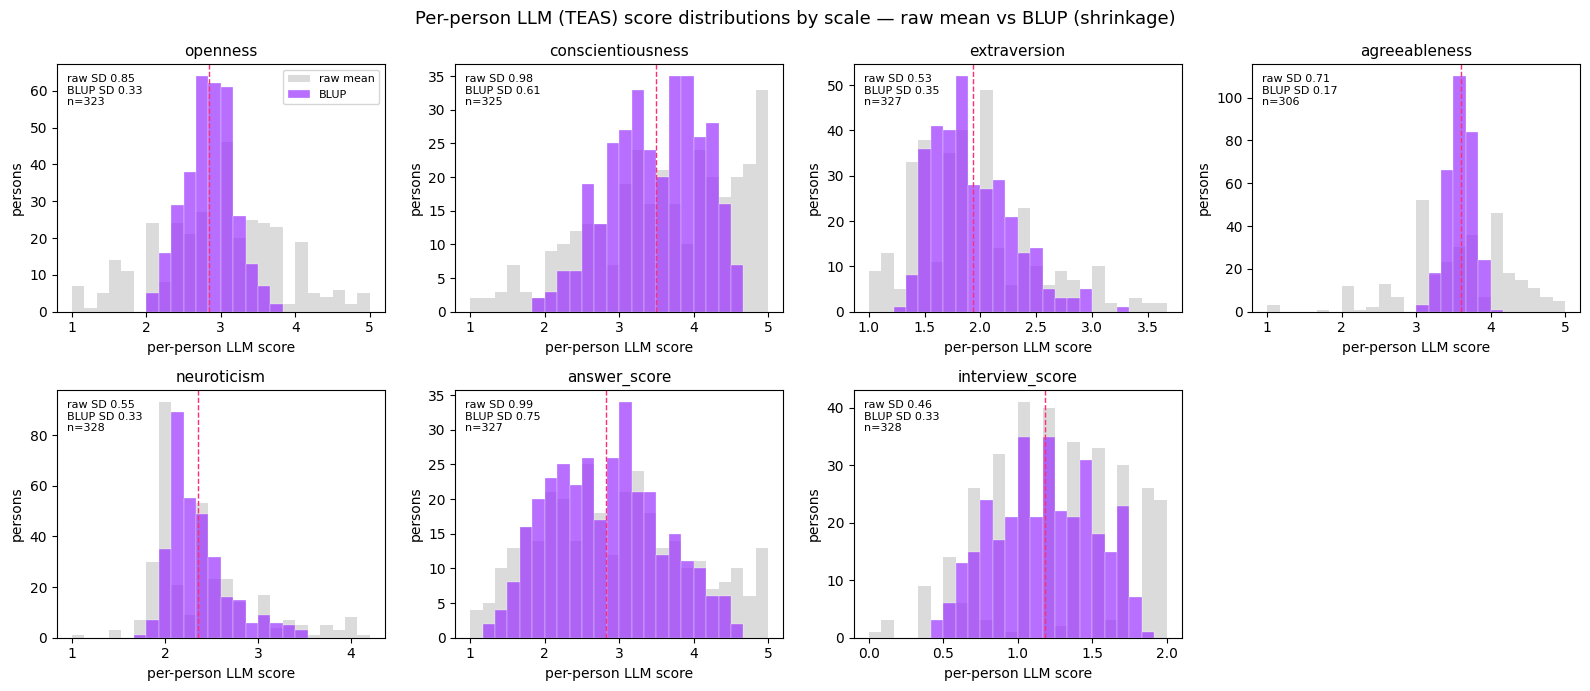

In [43]:
import matplotlib.pyplot as plt
import numpy as np
VIOLET, MAGENTA, GREY = "#9B30FF", "#FF2D78", "#B0B0B0"

bt = pd.read_csv("outputs/stage3_teas/teas_person_scores_blup.csv")
SC = ["openness","conscientiousness","extraversion","agreeableness","neuroticism","answer_score","interview_score"]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, s in zip(axes.ravel(), SC):
    raw, bl = bt[f"{s}_rawmean"].dropna(), bt[f"{s}_blup"].dropna()
    lo, hi = min(raw.min(), bl.min()), max(raw.max(), bl.max())
    bins = np.linspace(lo, hi, 25)                          # per-scale (TEAS scales differ: 1-5, 0-2)
    ax.hist(raw, bins=bins, color=GREY, alpha=.45, label="raw mean", edgecolor="none")
    ax.hist(bl, bins=bins, color=VIOLET, alpha=.70, label="BLUP", edgecolor="white", linewidth=.3)
    ax.axvline(bl.mean(), color=MAGENTA, ls="--", lw=1)
    ax.set_title(s, fontsize=11)
    ax.set_xlabel("per-person LLM score"); ax.set_ylabel("persons")
    ax.text(.03, .96, f"raw SD {raw.std():.2f}\nBLUP SD {bl.std():.2f}\nn={len(bl)}", transform=ax.transAxes,
            va="top", fontsize=8, bbox=dict(boxstyle="round", fc="white", ec="none", alpha=.75))
axes.ravel()[0].legend(fontsize=8, loc="upper right")
axes.ravel()[-1].axis("off")   # 8th panel empty (7 scales)
fig.suptitle("Per-person LLM (TEAS) score distributions by scale — raw mean vs BLUP (shrinkage)", fontsize=13)
fig.tight_layout()
plt.show()

## Section 4. Human ↔ LLM comparison (in progress)

### 4.1 Score distributions by scale
Smooth density (KDE) of each method's scores per scale. Human z-scores and LLM TEAS scores are each
standardised **within method** (mean 0 / SD 1) so the two shapes are comparable on one axis, and this
compares the **shape** of the distributions, not their level. LLM scores are discrete Likert
(1-5; interview_score 0-2), so their curve shows a coarser granularity than the continuous human z.

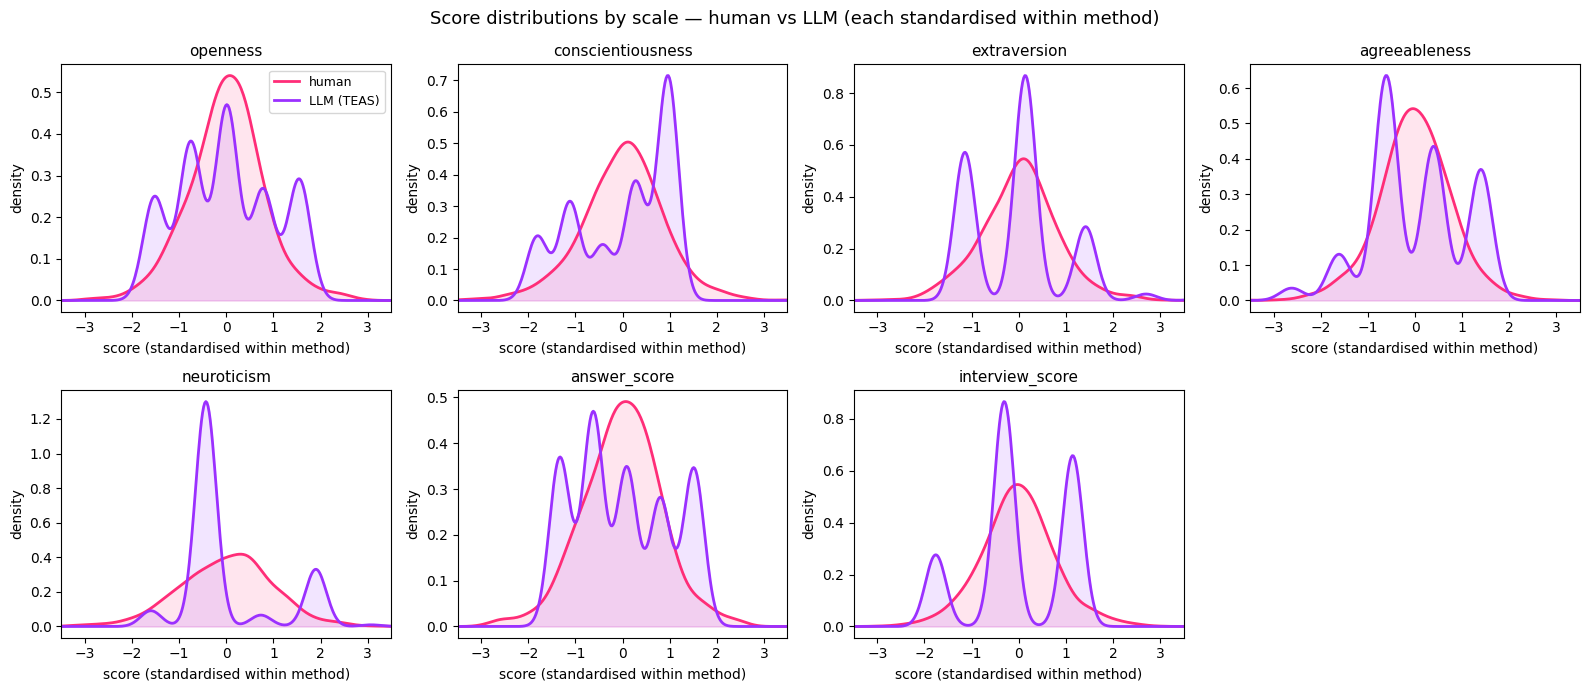

In [44]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

HUMAN_C, LLM_C = "#FF2D78", "#9B30FF"
SC = ["openness","conscientiousness","extraversion","agreeableness","neuroticism","answer_score","interview_score"]

ana = pd.read_csv("data/recruitview_analysis.csv")
teas = pd.read_csv("experiments/evaluation_of_gemini_outputs/results/teas_run2_gpt-4o-mini.csv")
m = ana[["response_id"] + SC].merge(teas[["response_id"] + [f"E_{s}" for s in SC]], on="response_id", how="left")

def zc(x):
    x = x.dropna()
    return (x - x.mean()) / x.std()

grid = np.linspace(-3.5, 3.5, 300)
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, s in zip(axes.ravel(), SC):
    for data, c, lab in [(zc(m[s]), HUMAN_C, "human"), (zc(m[f"E_{s}"]), LLM_C, "LLM (TEAS)")]:
        dens = gaussian_kde(data)(grid)
        ax.plot(grid, dens, color=c, lw=2, label=lab)
        ax.fill_between(grid, dens, color=c, alpha=.12)
    ax.set_title(s, fontsize=11)
    ax.set_xlabel("score (standardised within method)"); ax.set_ylabel("density")
    ax.set_xlim(-3.5, 3.5)
axes.ravel()[0].legend(fontsize=9, loc="upper right")
axes.ravel()[-1].axis("off")   # 8th panel empty (7 scales)
fig.suptitle("Score distributions by scale — human vs LLM (each standardised within method)", fontsize=13)
fig.tight_layout()
plt.show()

### 4.2 Human ↔ LLM convergence per scale (summary scores)
Correlation of the **per-person summary score** (EB/BLUP, one value per participant) between the two methods, per scale. 
Pearson `r` and Spearman `rho` on the 328 persons (fewer where the LLM abstained: openness / agreeableness). `n` = persons scored by both methods.

In [48]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

SC = ["openness","conscientiousness","extraversion","agreeableness","neuroticism","answer_score","interview_score"]
h = pd.read_csv("outputs/stage2_human/human_person_scores_blup.csv").set_index("user_no")
t = pd.read_csv("outputs/stage3_teas/teas_person_scores_blup.csv").set_index("user_no")

rows = []
for s in SC:
    m = pd.DataFrame({"human": h[f"{s}_blup"], "llm": t[f"{s}_blup"]}).dropna()
    r, pr = pearsonr(m.human, m.llm)
    rho, _ = spearmanr(m.human, m.llm)
    rows.append(dict(scale=s, n=len(m), pearson_r=round(r, 3),
                     spearman_rho=round(rho, 3), p_value=round(pr, 4)))
tab = pd.DataFrame(rows)

print("Human <-> LLM convergence — per-person BLUP summary scores, per scale\n")
print(tab.to_string(index=False))
print(f"\nmean Pearson r across scales: {tab.pearson_r.mean():+.3f}")


Human <-> LLM convergence — per-person BLUP summary scores, per scale

            scale   n  pearson_r  spearman_rho  p_value
         openness 323     -0.376        -0.413   0.0000
conscientiousness 325     -0.486        -0.505   0.0000
     extraversion 327     -0.425        -0.459   0.0000
    agreeableness 306     -0.226        -0.261   0.0001
      neuroticism 328     -0.281        -0.292   0.0000
     answer_score 327     -0.605        -0.611   0.0000
  interview_score 328     -0.632        -0.656   0.0000

mean Pearson r across scales: -0.433
